Connected to mne (Python 3.12.8)

In [ ]:
import mne
import os
import numpy as np
from mne.datasets import sample
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs, find_bad_channels_maxwell
from mne_icalabel import label_components
from autoreject import AutoReject # for rejecting bad channels
from autoreject import get_rejection_threshold  
from collections import Counter
from pyprep.find_noisy_channels import NoisyChannels
#from pyprep import PreprocessingPipeline

In [ ]:
pilot_dir = '/Users/denizyilmaz/Desktop/eeg_test_data/RNet and Slim Test'

In [ ]:
os.chdir(pilot_dir)

In [ ]:
# I run this to get the name of my file I want to read
os.listdir()

# read data that you already put in your wd
#raw = mne.io.read_raw("BTSCZ008_V1_eyes-open.vhdr", preload=True)
raw = mne.io.read_raw("test_slim_32_ec.vhdr", preload=True)


# alternative way of reading data
# raw = mne.io.read_raw_brainvision("BTSCZ009_V1_eyes-open.vhdr", preload=True, scale=1)
# read_raw_brainvision(scale=1e6)

# inspect data visually
raw.plot()

Extracting parameters from test_slim_32_ec.vhdr...
Setting channel info structure...
Reading 0 ... 138859  =      0.000 ...   277.718 secs...


<ipython-input-7-5e35869db428>:6: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw("test_slim_32_ec.vhdr", preload=True)
<ipython-input-7-5e35869db428>:6: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (1000.00 Hz) will be stored.
  raw = mne.io.read_raw("test_slim_32_ec.vhdr", preload=True)
2026-04-29 12:02:03,176 - OpenGL.acceleratesupport - INFO - No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


Using qt as 2D backend.
Using pyopengl with version 3.1.6


Channels marked as bad:
none


In [ ]:
# you can get specific info by calling an attribute like a dict
print(raw.info["sfreq"])  # u get sampling frequency
print(raw.info["bads"])  # u get the bad channels IF marked beforehand

500.0
[]


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
<RawBrainVision | test_slim_32_ec.eeg, 33 x 138860 (277.7 s), ~35.0 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  Fp1   EEG   µV      -230.50     -30.50     -15.50      -1.00     168.00
 1  Fp2   EEG   µV      -494.00     -18.50       1.00      19.50     191.00
 2  F7    EEG   µV      -118.50      -7.50       9.00      27.00     134.00
 3  F3    EEG   µV       -57.50       1.50       8.50      15.00      70.50
 4  Fz    EEG   µV       -85.00     -48.50     -41.50     -34.00       5.00
 5  F4    EEG   µV       -66.00     -23.50      25.50     106.50     191.00
 6  F8    EEG   µV      -250.50      10.50      19.00      27.50     121.00
 7  FC5   EEG   µV       -66.00       0.50       8.50      15.50      91.00
 8  FC1   EEG   µV      -115.50     -30.50     -25.00     -19.50      7

<ipython-input-9-f84cbaa8a36a>:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


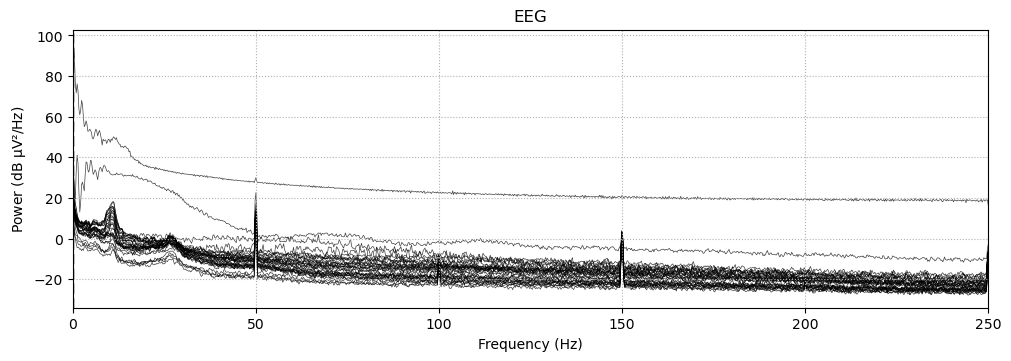

In [ ]:
raw.plot_psd()

# describe raw data
raw.describe()
print(type(raw._data))
print(raw._data.shape)
#raw_data = raw.get_data

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'T5', 'P3', 'Pz', 'P4', 'T6', 'PO9', 'O1', 'ECG', 'O2', 'PO10', 'RESP']


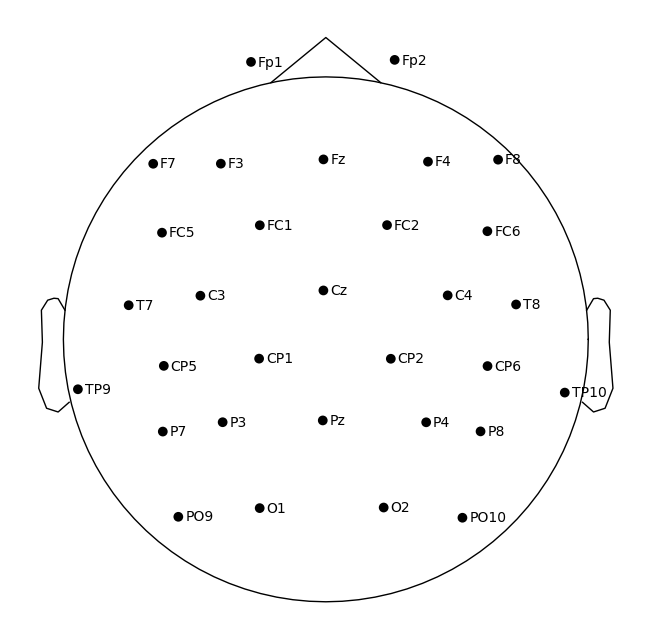

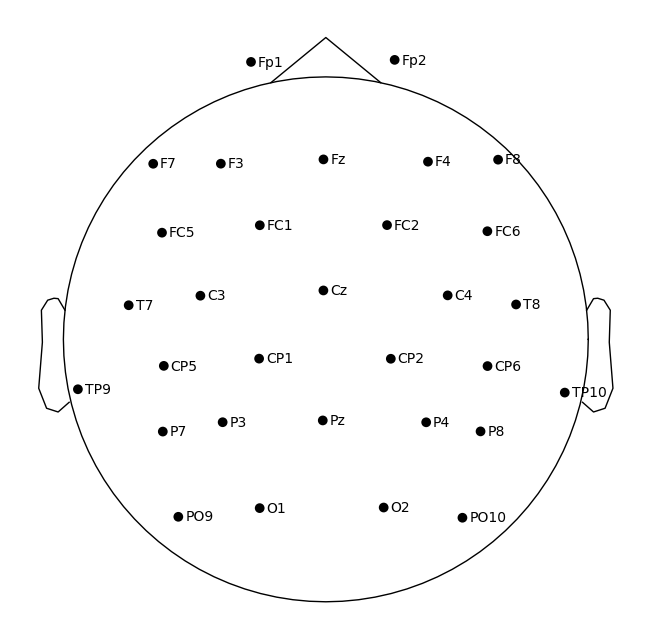

In [ ]:
# check our channel names
print(raw.ch_names)
# some channels are named according to the old nomenclature, change them
# Create a dictionary to map old channel names to new channel names
channel_renaming = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8',
}

# Rename the channels using rename_channels
raw.rename_channels(channel_renaming)

# Check if "RESP" channel is present
if 'RESP' in raw.ch_names:
    # Define the channel type mapping
    channel_type_mapping = {
        'ECG': 'ecg',
        'RESP': 'resp'
    }
    
    # Set the channel types for "ECG" and "RESP" channels
    raw.set_channel_types(channel_type_mapping)
else:
    # Define the channel type mapping for only ECG channel if no RESP
    channel_type_mapping = {
        'ECG': 'ecg'
    }

    # Set the channel type for the "ECG" channel
    raw.set_channel_types(channel_type_mapping)

# Load the easycap-M1 montage (check if its truw by checking the cap)
montage = mne.channels.make_standard_montage('standard_1020')

# Apply the montage to your raw data
raw.set_montage(montage)

# plot montage
raw.plot_sensors(show_names=True)

In [ ]:
# Define the new sampling rate you want
new_sampling_rate = 250 

# Resample the EEG data to the new sampling rate
raw_resampled = raw.copy()
raw_resampled.resample(sfreq=new_sampling_rate)

print(raw_resampled.info["sfreq"])

250.0


In [ ]:
# find ECG events
ecg_events, _, _ = mne.preprocessing.find_ecg_events(raw_resampled, ch_name='ECG')
# play with the detection threshold and see if it performs better!

# Create annotations time-locked to R-peak with event descriptions
descriptions = ['R-peak'] * len(ecg_events)
R_peak_annotations = mne.Annotations(onset=ecg_events[:, 0] / raw_resampled.info['sfreq'],  # Convert sample indices to seconds
                              duration=0.0,  # Set the duration to zero for point events
                              description=descriptions)

# Define existing annotations
hct_annotations = raw.annotations.copy()

# Combine initial and R-peaks annotations
combined_annotations = mne.Annotations(
    onset=np.concatenate((hct_annotations.onset, R_peak_annotations.onset)),
    duration=np.concatenate((hct_annotations.duration, R_peak_annotations.duration)),
    description=np.concatenate((hct_annotations.description, R_peak_annotations.description))
)

# Apply annotations to raw data
raw_resampled.set_annotations(combined_annotations)

# Plot ECG with Annotations
raw_resampled.plot(n_channels=1, scalings={'ECG': 1e-3})
raw_resampled.plot(n_channels=1)

# YAY WORKS WELL UNTIL HERE!

# ecg_events.plot_image(combine="mean")

Using channel ECG to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 2500 samples (10.000 s)

Number of ECG events detected : 352 (average pulse 76.0478179461328 / min.)
Using pyopengl with version 3.1.6
Using pyopengl with version 3.1.6


In [ ]:
# Create a copy of the original RawBrainVision object
raw_eeg = raw_resampled.copy()

# Remove non-EEG channels
if 'RESP' in raw_eeg.ch_names:
    raw_eeg.drop_channels(['ECG', 'RESP'])
else:
    raw_eeg.drop_channels(['ECG'])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


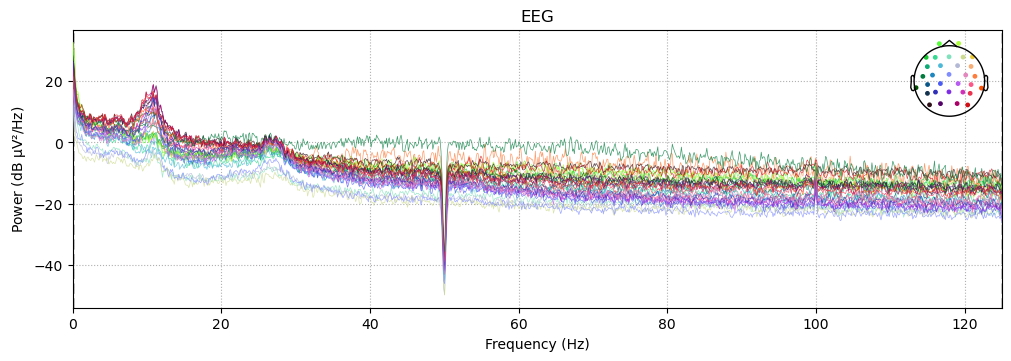

In [ ]:
# Apply notch filter to remove line noise (e.g., 50 Hz from Antonin's manuscript)
line_freq = 50  # Set the line frequency to 50, as Antonin did: 
raw_resampled_line= raw_resampled.copy()
raw_resampled_line.notch_filter(freqs=line_freq)  # Apply notch filter to EEG channels only ?? OR: 49.5 to 50.5 in a method ??
# Plot the data to visualize the effect of the notch filter
raw_resampled_line.plot_psd()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Using pyopengl with version 3.1.6
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


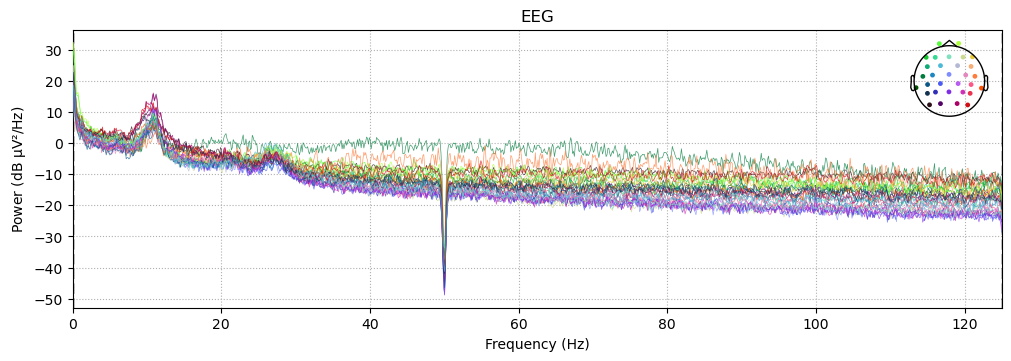

Channels marked as bad:
none


In [ ]:
# B.Robust average rereferencing
raw_resampled_line_reref = raw_resampled_line.copy()
raw_resampled_line_reref.set_eeg_reference(ref_channels='average')
raw_resampled_line_reref.plot()
raw_resampled_line_reref.plot_psd()

In [ ]:
raw_resampled_line_reref_interp = raw_resampled_line_reref.copy()
# Assign the mne object to the NoisyChannels class. The resulting object will be the place where all following methods are performed.
noisy_data = NoisyChannels(raw_resampled_line_reref, random_state=1337)
# find bad by corr
noisy_data.find_bad_by_correlation()
print("Bad channels by correlation:", noisy_data.bad_by_correlation)
# find bad by deviation
noisy_data.find_bad_by_deviation()
print("Bad channels by deviation:", noisy_data.bad_by_deviation)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Bad channels by correlation: ['T7', 'T8']
Bad channels by deviation: []


In [ ]:
#find bad by ransac: finds nothing, do I first have to mark bads from the methods before?  acc to Bigdely-Shamlo paper most bads are found in corr and dev
noisy_data.find_bad_by_ransac(channel_wise=True, max_chunk_size=1) 
print("Bad channels by RANSAC:", noisy_data.bad_by_ransac)

Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 1
Total # of chunks: 29
Current chunk:
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29

RANSAC done!
Bad channels by RANSAC: [np.str_('FC1')]


In [ ]:
raw_resampled_line_reref_interp.info["bads"] = noisy_data.get_bads()
bads = noisy_data.get_bads()

In [ ]:
bads

['T8', np.str_('FC1'), 'T7']

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 97.0 mm
Computing interpolation matrix from 28 sensor positions
Interpolating 3 sensors
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


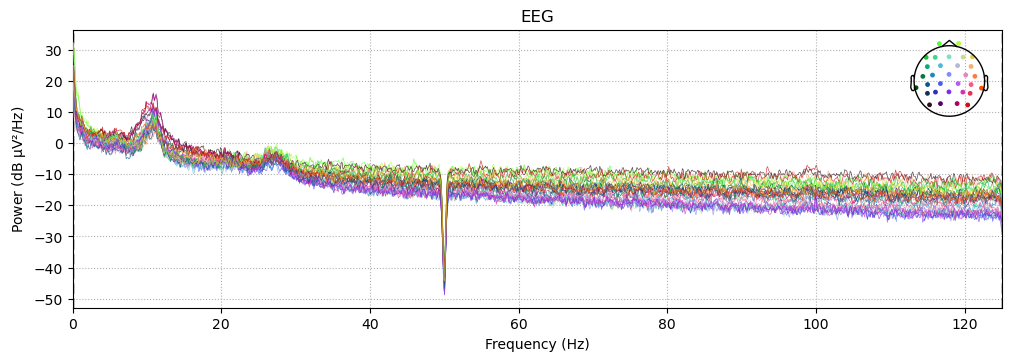

In [ ]:
raw_resampled_line_reref_interp.interpolate_bads()
# plot psd
raw_resampled_line_reref_interp.plot_psd()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 2751 samples (11.004 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


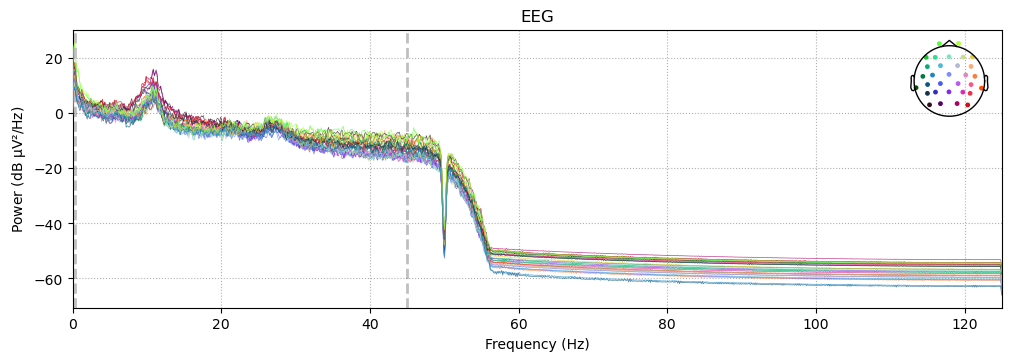

In [ ]:
raw_resampled_line_reref_interp_filt = raw_resampled_line_reref_interp.copy()
# Define the bandpass filter frequency range
low_freq = 0.3  # Lower cutoff frequency (in Hz)
#low_freq = 1
high_freq = 45.0  # Upper cutoff frequency (in Hz)
# Apply the bandpass filter
raw_resampled_line_reref_interp_filt.filter(l_freq=low_freq, h_freq=high_freq, method='fir', phase='zero') # check method and phase
# plot psd
raw_resampled_line_reref_interp_filt.plot_psd()

In [ ]:
# for ICA to perform better we need filter 1, THEN copy weights back to filter .3
raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=1.0, h_freq=None)
# you can try and see lower for heart artifacts but other components may get worse
#raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=0.1, h_freq=None)

# Channels to exclude from threshold check (eye movement channels)
exclude_channels = ['Fp1', 'Fp2', 'F7', 'F8']
#include_channels = mne.pick_channels(epochs.ch_names, include = [], exclude=exclude_channels)
# exclude channels cclose to the eyes: we want to detect eye movements w ICA 
raw_ica_no_eyes = raw_ica.drop_channels(exclude_channels)


# epoch data for 1 sec to reject  bad epochs
# Define the duration of each epoch in seconds
epoch_duration = 1.0
# Create epochs on the data you prepared
epochs = mne.make_fixed_length_epochs(raw_ica_no_eyes, duration=epoch_duration, preload=True)

# describe a  bad epoch: CHECK THESE VALS! 
reject_criteria = dict(eeg=100e-6)  # 100 µV, same as Antonin
# HERE for reject: (excluding channels that reflected eye movements, i.e., EOG channels, Fp1, Fp2, F7, F8) 
flat_criteria = dict(eeg=1e-6)  # 1 µV
# reject bad epochs
epochs_cleaned = epochs.copy().drop_bad(reject_criteria, flat_criteria)
epochs_cleaned.plot_drop_log()
print(epochs.drop_log) # or epochs_cleaned?

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Not setting metadata
277 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 277 events and 250 original time points ...
0 bad epochs dropped
0 bad epochs dropped
((), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [ ]:
total_epoch_nr = epochs.get_data().shape[0]
# Convert the drop log to binary values (1 if dropped, 0 if not)
binary_drop_log = [[1 if ch in log else 0 for ch in epochs_cleaned.ch_names] for log in epochs_cleaned.drop_log]

# Calculate the percentage of epochs dropped for each channel
channel_drop_percentage = {ch_name: sum(log) / total_epoch_nr * 100 
                           for ch_name, log in zip(epochs_cleaned.ch_names, zip(*binary_drop_log))}

# Set the threshold for drop percentage
threshold_percentage = 33.0

# Print channel names with drop percentage above the threshold
bad_channels = []
for ch_name, percentage in channel_drop_percentage.items():
    if percentage > threshold_percentage:
        print(f"Channel {ch_name}: {percentage:.2f}% epochs dropped")
        bad_channels.append(ch_name)

In [ ]:
bad_channels

[]

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by number: 27 components


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA took 0.7s.
Fraction of eeg variance explained by all components: 0.9992943146637623
Creating RawArray with float64 data, n_channels=28, n_times=69430
    Range : 0 ... 69429 =      0.000 ...   277.716 secs
Ready.
Using pyopengl with version 3.1.6


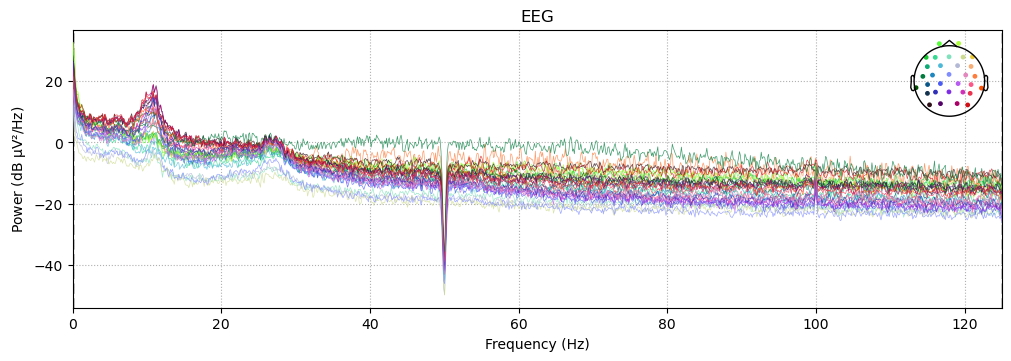

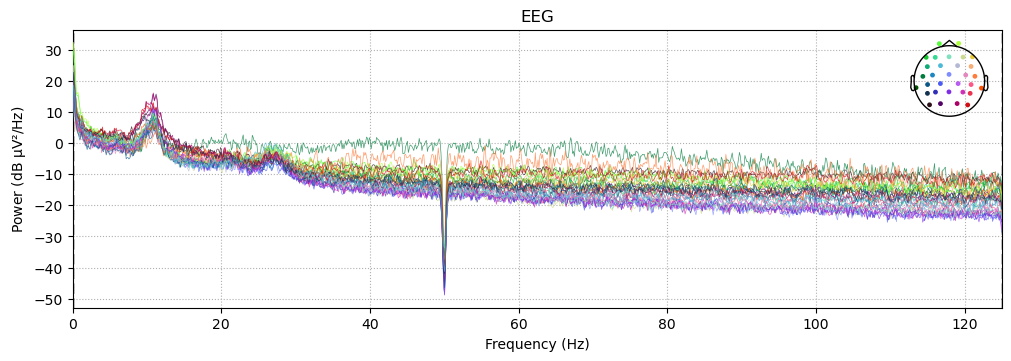

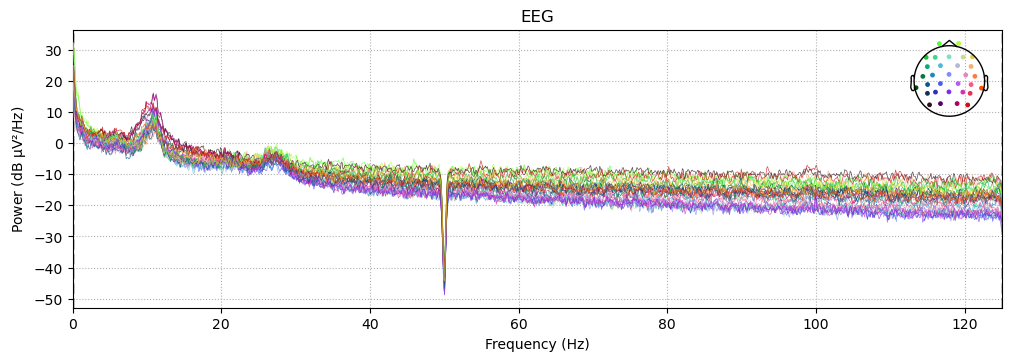

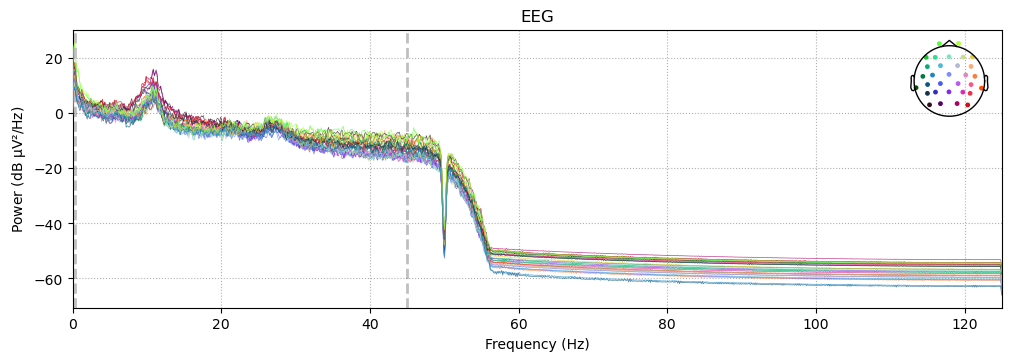

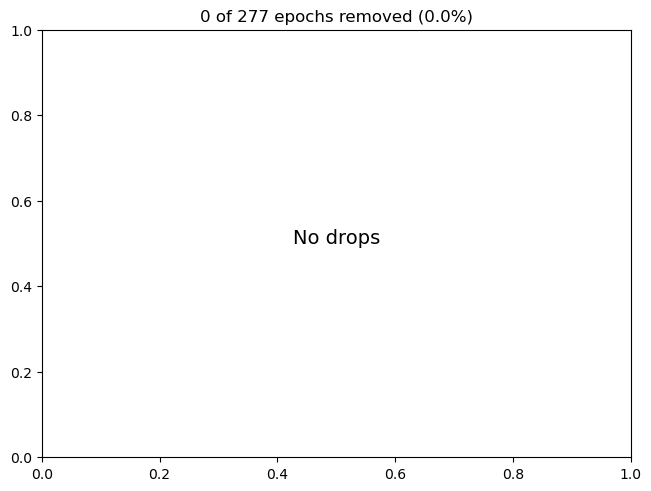

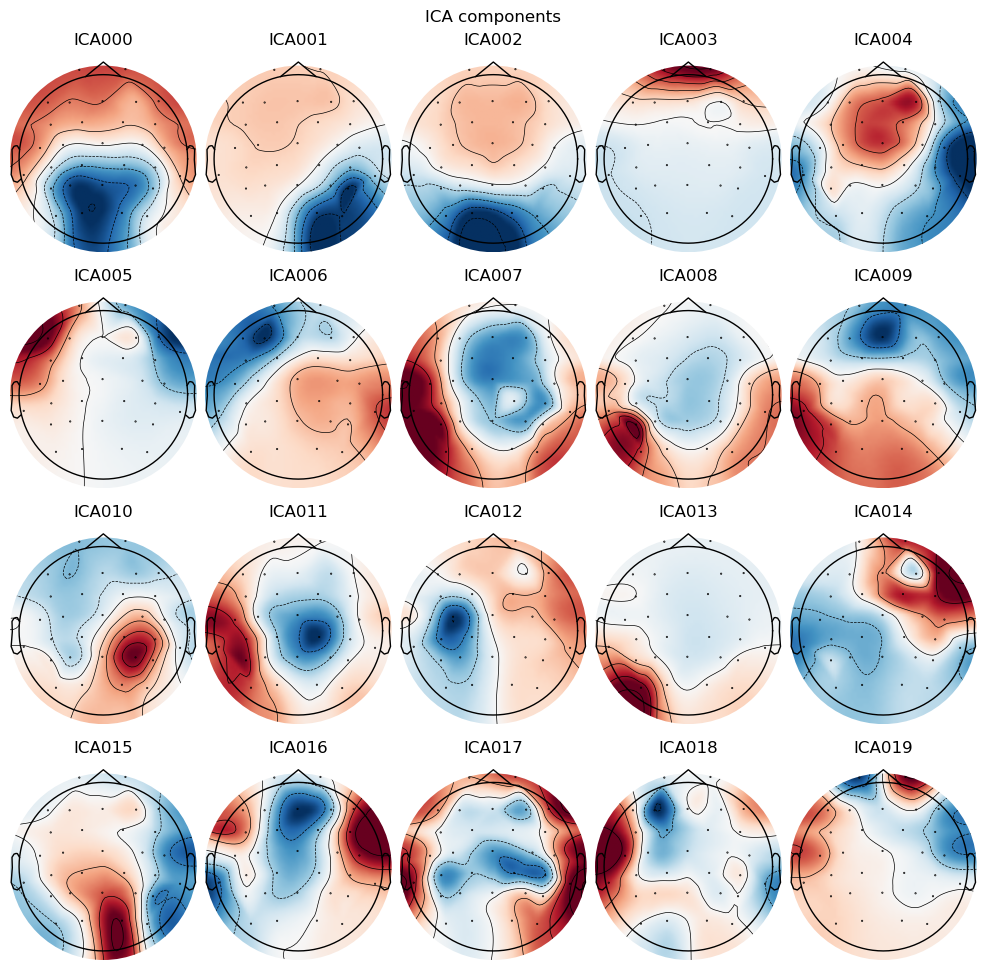

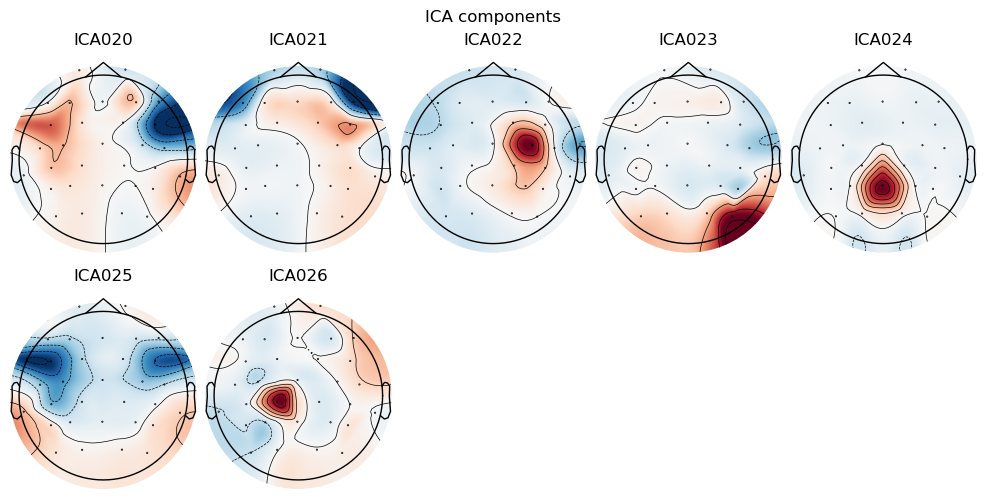

[<MNEFigure size 975x967 with 20 Axes>, <MNEFigure size 975x496 with 7 Axes>]

Channels marked as bad:
none
Channels marked as bad:
none


In [ ]:
raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=1.0, h_freq=None)
# you can try and see lower for heart artifacts but other components may get worse
#raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=0.1, h_freq=None)


# set up and fit the ICA
ica = ICA(n_components=27, max_iter="auto", random_state=97) # initially 30
ica.fit(raw_ica)
ica

# print explained vars for ICAs
explained_var_ratio = ica.get_explained_variance_ratio(raw_ica)
for channel_type, ratio in explained_var_ratio.items():
    print(
        f"Fraction of {channel_type} variance explained by all components: " f"{ratio}"
    )

# plot ICs
raw_ica.load_data()
ica.plot_sources(raw_ica, show_scrollbars=False)
ica.plot_components()

In [ ]:
component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')
# component_labels gives the labels

# Print the results
print("Predicted Probabilities:", component_dict['y_pred_proba'])
print("Component Labels:", component_dict['labels'])

# Extract the labels and probabilities
labels = component_dict['labels']
probabilities = component_dict['y_pred_proba']

<ipython-input-26-f8386600f8c9>:1: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')
<ipython-input-26-f8386600f8c9>:1: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')


Predicted Probabilities: [0.9999483  0.9992636  0.9999016  0.9822223  0.9439237  0.99835515
 0.97651297 0.899591   0.8781185  0.796441   0.99991095 0.98811644
 0.9955963  0.8918479  0.41852754 0.99945176 0.5018331  0.8294611
 0.79530525 0.48818251 0.7933743  0.777418   0.9806943  0.81965256
 0.97941077 0.6109967  0.72107   ]
Component Labels: ['brain', 'brain', 'brain', 'eye blink', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'other', 'brain', 'other', 'other', 'other', 'muscle artifact', 'other', 'eye blink', 'brain', 'brain', 'brain', 'muscle artifact', 'brain']


In [ ]:
exclude_components = [
    idx for idx, (label, prob) in enumerate(zip(labels, probabilities))
    if label != 'brain' or prob < 0.5
]

# Print excluded components for verification
print(f"Excluding components: {exclude_components}")

# Remove the identified components from the preprocessed data
ica.exclude = exclude_components
raw_cleaned = ica.apply(raw_resampled_line_reref_interp_filt.copy())

Excluding components: [3, 5, 14, 16, 17, 18, 19, 20, 21, 25]
Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 10 ICA components
    Projecting back using 31 PCA components


In [ ]:
raw_cleaned.plot()

Using pyopengl with version 3.1.6


Channels marked as bad:
none


In [ ]:
raw_resampled_line_reref_interp_filt.plot(title="Before ICA Cleaning")

Using pyopengl with version 3.1.6


Channels marked as bad:
none


In [ ]:
raw_cleaned.plot(title="After ICA Cleaning")

Using pyopengl with version 3.1.6


Channels marked as bad:
none


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


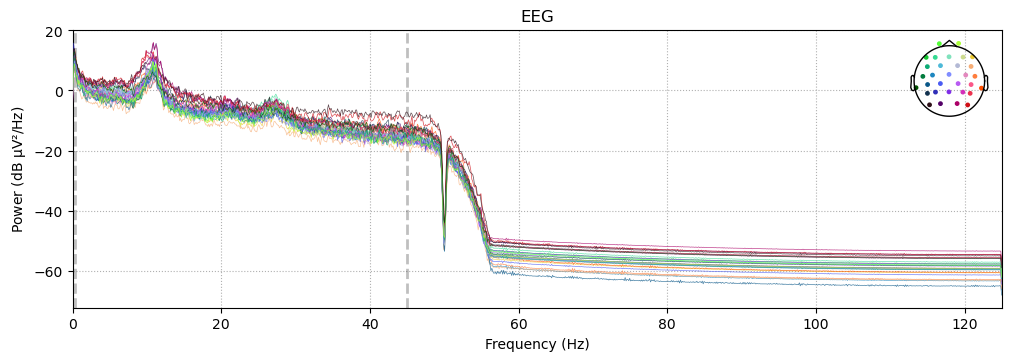

In [ ]:
raw_resampled_line_reref_interp_filt.plot_psd()
raw_cleaned.plot_psd()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


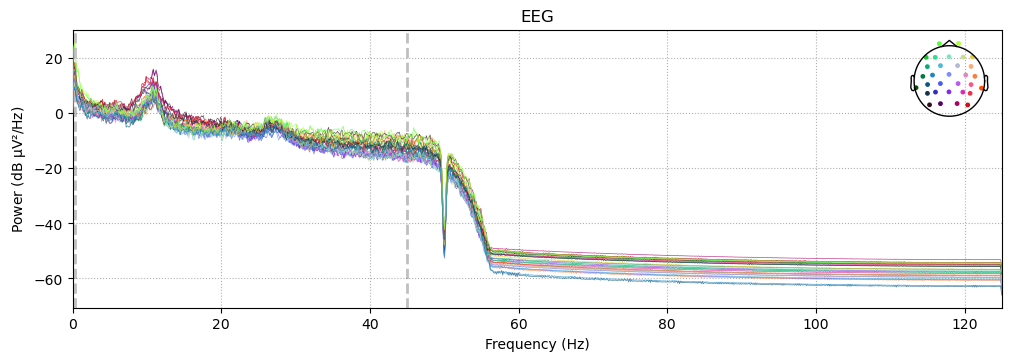

In [ ]:
raw_resampled_line_reref_interp_filt.plot_psd()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


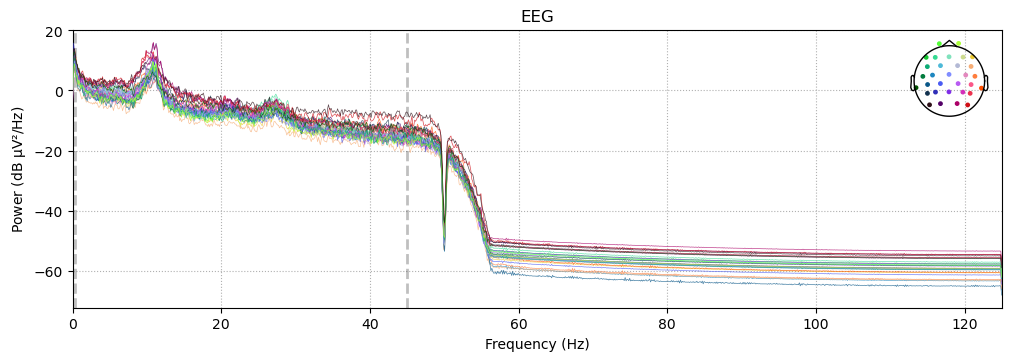

In [ ]:
raw_cleaned.plot_psd()

Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 10 ICA components
    Projecting back using 31 PCA components


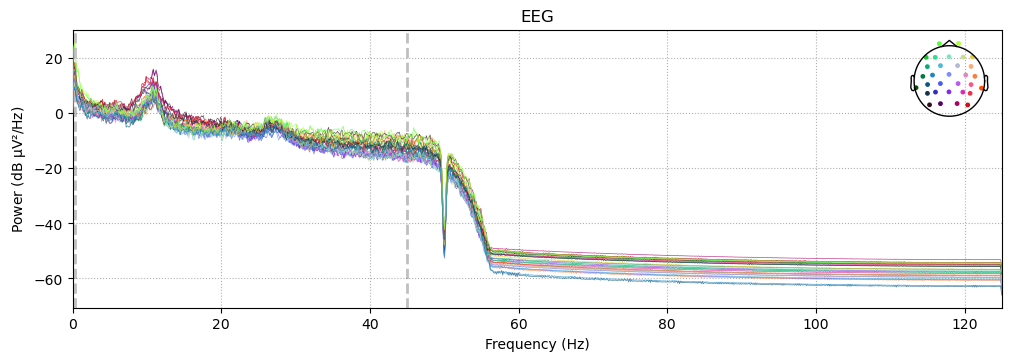

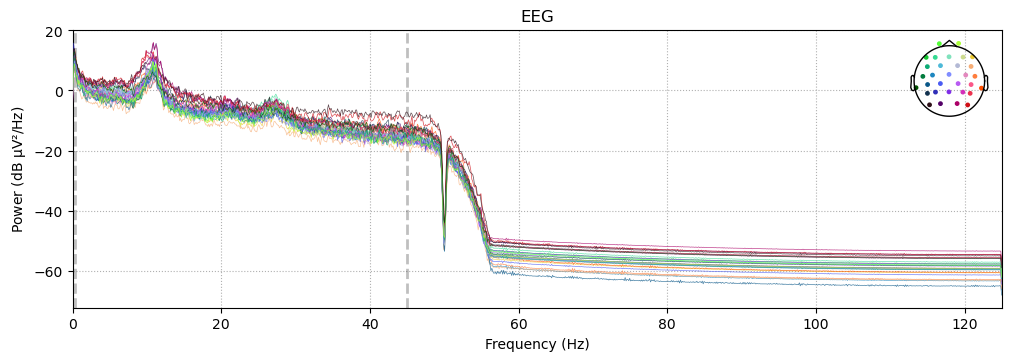

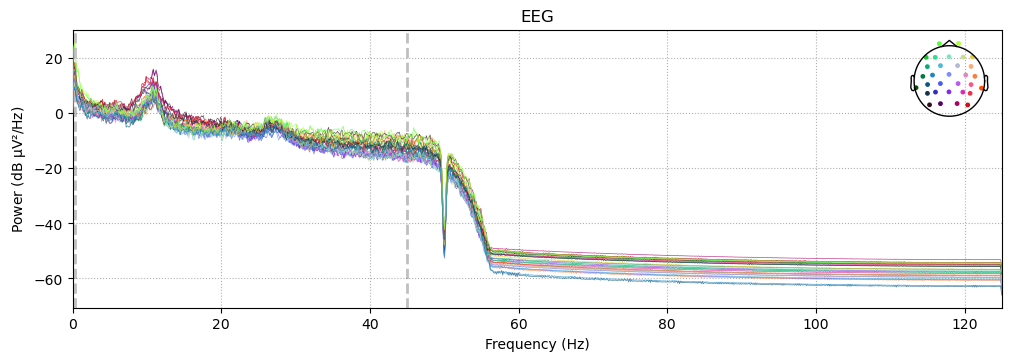

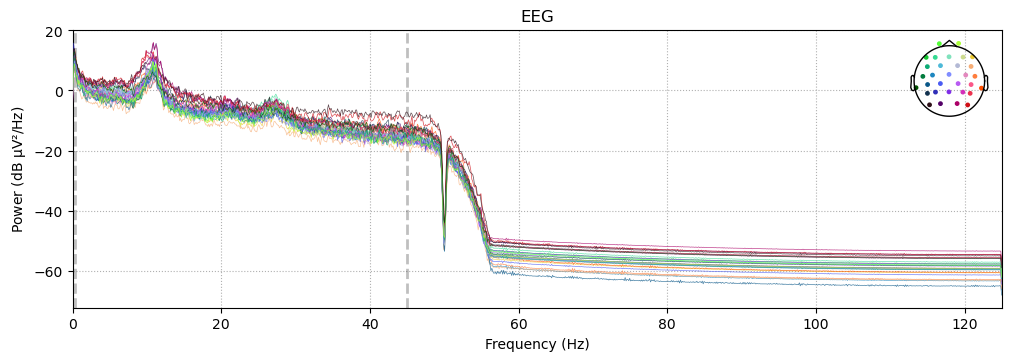

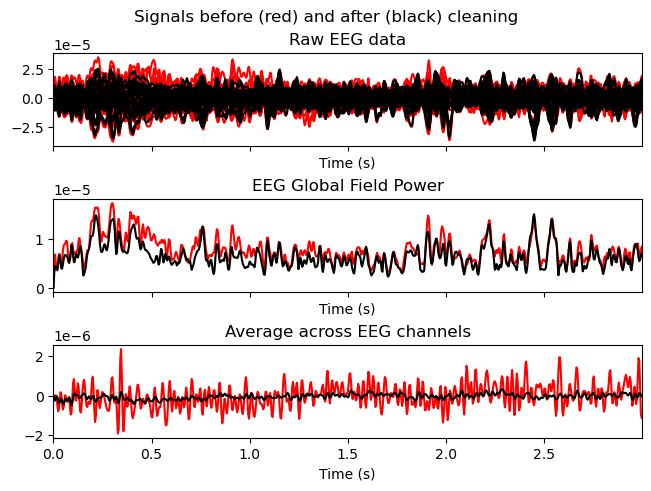

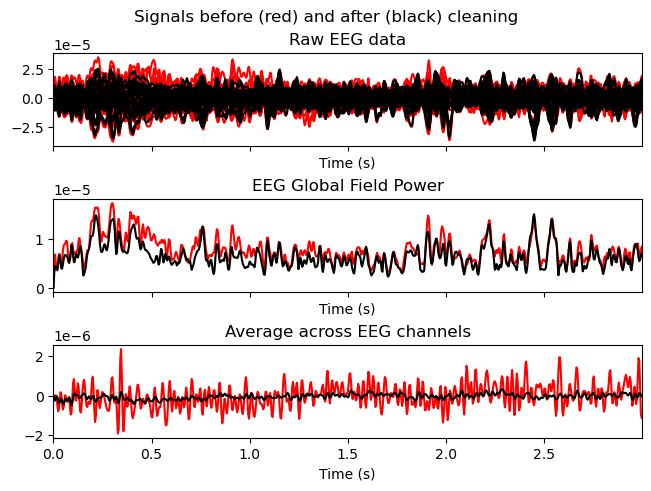

In [ ]:
ica.plot_overlay(raw_resampled_line_reref_interp_filt, exclude=ica.exclude)

In [ ]:
heartbeat_events, event_id = mne.events_from_annotations(raw_resampled)

heartbeat_epochs = mne.Epochs(
    raw_resampled_line_reref_interp_filt, heartbeat_events,
    event_id=event_id, tmin=-0.3, tmax=0.8, 
    baseline=(None, 0), preload=True, event_repeated='drop'
)

heartbeat_evoked = heartbeat_epochs.average()
heartbeat_evoked.plot

Used Annotations descriptions: [np.str_('Comment/actiCAP Data On'), np.str_('New Segment/'), np.str_('R-peak')]
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
353 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 353 events and 276 original time points ...
1 bad epochs dropped


<bound method Evoked.plot of <Evoked | '0.00 × New Segment/ + 1.00 × R-peak' (average, N=352), -0.3 – 0.8 s, baseline -0.3 – 0 s, 31 ch, ~109 KiB>>

In [ ]:
heartbeat_evoked.plot

<bound method Evoked.plot of <Evoked | '0.00 × New Segment/ + 1.00 × R-peak' (average, N=352), -0.3 – 0.8 s, baseline -0.3 – 0 s, 31 ch, ~109 KiB>>

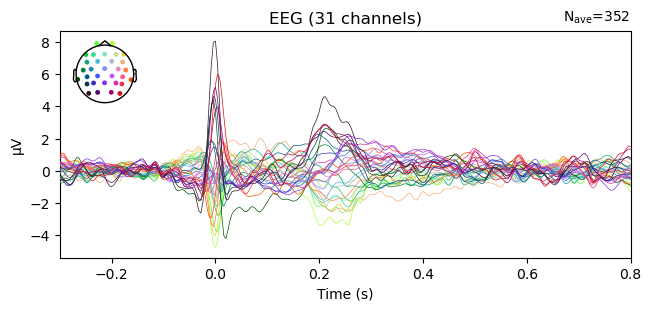

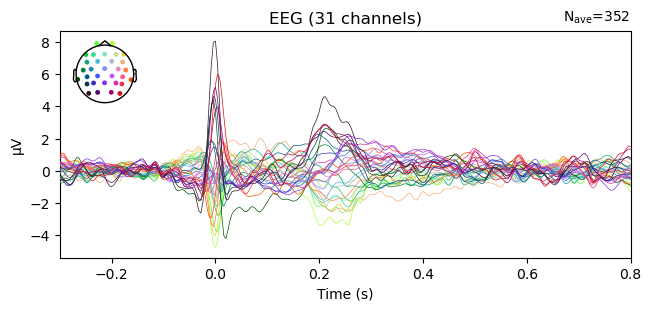

In [ ]:
heartbeat_evoked.plot()

In [ ]:
"""
.eeg: This file contains the actual EEG data. It's the raw EEG signal data you want to analyze.

.vhdr: This is the header file, and it contains metadata and information about the EEG recording, such as channel names, sampling rate, and electrode locations. This file is essential for interpreting the EEG data correctly.

.vmrk: This file contains event markers or annotations that correspond to events in the EEG data. Event markers can be used to mark the timing of specific events or stimuli during the EEG recording. This file is useful for event-related analyses.
"""

# I run this to get the name of my file I want to read
os.listdir()

# read data that you already put in your wd
#raw = mne.io.read_raw("BTSCZ008_V1_eyes-open.vhdr", preload=True)
raw = mne.io.read_raw("test_slim_32_eo.vhdr", preload=True)


# alternative way of reading data
# raw = mne.io.read_raw_brainvision("BTSCZ009_V1_eyes-open.vhdr", preload=True, scale=1)
# read_raw_brainvision(scale=1e6)

# inspect data visually
raw.plot()

"""
You can use raw.apply_function() for this purpose. 
MNE expects the unit of EEG signals to be V, so because your data is presumably in µV you could convert it like this: 
raw.apply_function(lambda x: x * 1e-6)
https://mne.discourse.group/t/rescale-data-import-from-fieldtrip/3402
"""

Extracting parameters from test_slim_32_eo.vhdr...
Setting channel info structure...
Reading 0 ... 208149  =      0.000 ...   416.298 secs...


<ipython-input-39-3c0804b3c5a1>:15: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw("test_slim_32_eo.vhdr", preload=True)
<ipython-input-39-3c0804b3c5a1>:15: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (1000.00 Hz) will be stored.
  raw = mne.io.read_raw("test_slim_32_eo.vhdr", preload=True)


Using pyopengl with version 3.1.6


'\nYou can use raw.apply_function() for this purpose. \nMNE expects the unit of EEG signals to be V, so because your data is presumably in µV you could convert it like this: \nraw.apply_function(lambda x: x * 1e-6)\nhttps://mne.discourse.group/t/rescale-data-import-from-fieldtrip/3402\n'

Channels marked as bad:
none


In [ ]:
# you can get specific info by calling an attribute like a dict
print(raw.info["sfreq"])  # u get sampling frequency
print(raw.info["bads"])  # u get the bad channels IF marked beforehand

"""
# first run an algoritm to detect bads:
# works only on epochs!? should I do this on epochs Im so confuseddddd
# aNYWAY check the MNE post u made
raw_check_bads = raw.copy()

auto_reject = AutoReject()
raw_no_bads = auto_reject.fit_transform(raw_check_bads)  

"""

# plot power spectral density
raw.plot_psd()

# describe raw data
raw.describe()
print(type(raw._data))
print(raw._data.shape)
#raw_data = raw.get_data()
#print(raw_data.shape)

500.0
[]
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
<RawBrainVision | test_slim_32_eo.eeg, 33 x 208150 (416.3 s), ~52.4 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  Fp1   EEG   µV      -133.50     -18.50      -4.00       9.50     313.00
 1  Fp2   EEG   µV      -335.50      -8.00      10.00      30.00     331.50
 2  F7    EEG   µV      -211.00       1.50      20.00      39.00     267.50
 3  F3    EEG   µV       -68.00      -1.50       6.00      13.50     270.00
 4  Fz    EEG   µV       -76.00     -39.00     -30.50     -21.50      90.50
 5  F4    EEG   µV      -106.00     -84.50     -70.50     -41.00       1.50
 6  F8    EEG   µV      -565.00      10.00      19.00      28.00     266.00
 7  FC5   EEG   µV      -203.50       4.00      11.00      17.50     189.00
 8  FC1   EEG   µV      -161.00     -27.00     -21.50     -16.

<ipython-input-40-fc713c7329e8>:19: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'T5', 'P3', 'Pz', 'P4', 'T6', 'PO9', 'O1', 'ECG', 'O2', 'PO10', 'RESP']


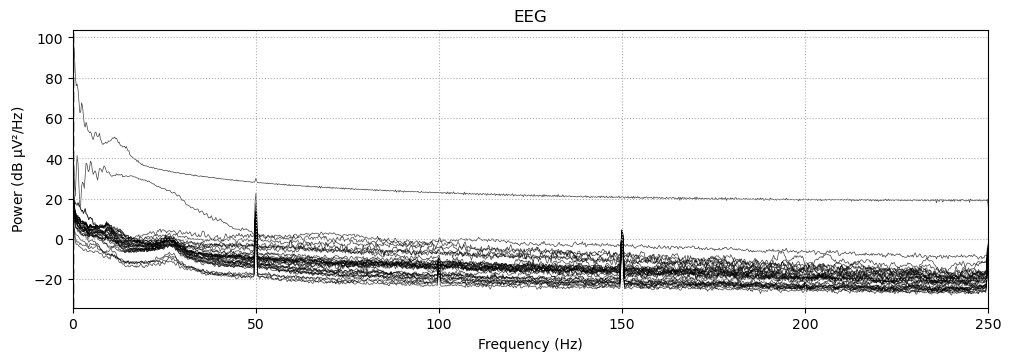

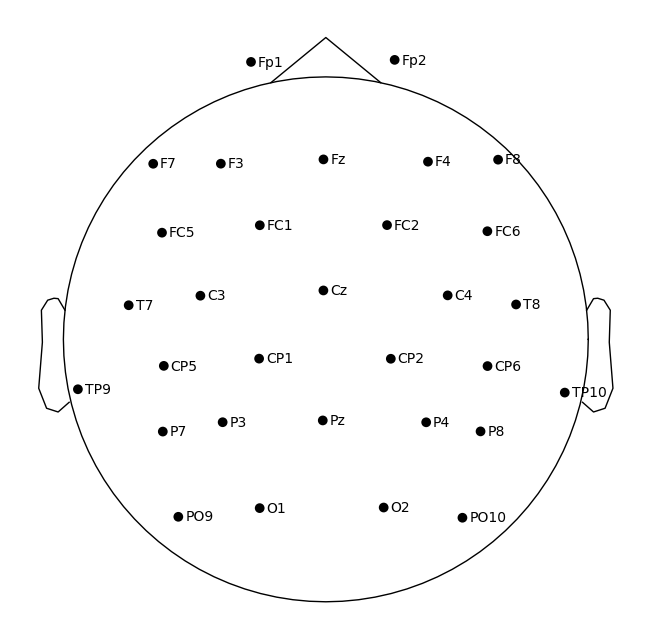

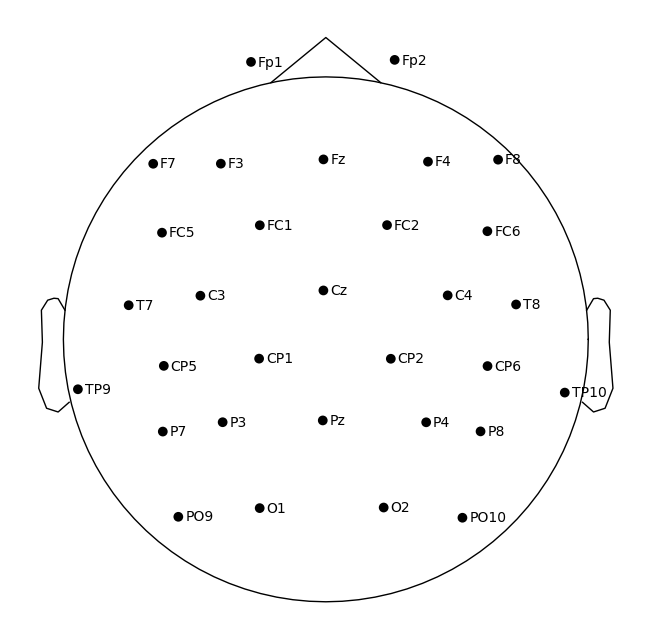

In [ ]:
# check our channel names
print(raw.ch_names)
# some channels are named according to the old nomenclature, change them
# Create a dictionary to map old channel names to new channel names
channel_renaming = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8',
}

# Rename the channels using rename_channels
raw.rename_channels(channel_renaming)

# Check if "RESP" channel is present
if 'RESP' in raw.ch_names:
    # Define the channel type mapping
    channel_type_mapping = {
        'ECG': 'ecg',
        'RESP': 'resp'
    }
    
    # Set the channel types for "ECG" and "RESP" channels
    raw.set_channel_types(channel_type_mapping)
else:
    # Define the channel type mapping for only ECG channel if no RESP
    channel_type_mapping = {
        'ECG': 'ecg'
    }

    # Set the channel type for the "ECG" channel
    raw.set_channel_types(channel_type_mapping)

# Load the easycap-M1 montage (check if its truw by checking the cap)
montage = mne.channels.make_standard_montage('standard_1020')

# Apply the montage to your raw data
raw.set_montage(montage)

# plot montage
raw.plot_sensors(show_names=True)

In [ ]:
# Define the new sampling rate you want
new_sampling_rate = 250 

# Resample the EEG data to the new sampling rate
raw_resampled = raw.copy()
raw_resampled.resample(sfreq=new_sampling_rate)

print(raw_resampled.info["sfreq"])

250.0


In [ ]:
# find ECG events
ecg_events, _, _ = mne.preprocessing.find_ecg_events(raw_resampled, ch_name='ECG')
# play with the detection threshold and see if it performs better!

# Create annotations time-locked to R-peak with event descriptions
descriptions = ['R-peak'] * len(ecg_events)
R_peak_annotations = mne.Annotations(onset=ecg_events[:, 0] / raw_resampled.info['sfreq'],  # Convert sample indices to seconds
                              duration=0.0,  # Set the duration to zero for point events
                              description=descriptions)

# Define existing annotations
hct_annotations = raw.annotations.copy()

# Combine initial and R-peaks annotations
combined_annotations = mne.Annotations(
    onset=np.concatenate((hct_annotations.onset, R_peak_annotations.onset)),
    duration=np.concatenate((hct_annotations.duration, R_peak_annotations.duration)),
    description=np.concatenate((hct_annotations.description, R_peak_annotations.description))
)

# Apply annotations to raw data
raw_resampled.set_annotations(combined_annotations)

# Plot ECG with Annotations
raw_resampled.plot(n_channels=1, scalings={'ECG': 1e-3})
raw_resampled.plot(n_channels=1)

# YAY WORKS WELL UNTIL HERE!

# ecg_events.plot_image(combine="mean")

Using channel ECG to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 2500 samples (10.000 s)

Number of ECG events detected : 530 (average pulse 76.38722075426375 / min.)
Using pyopengl with version 3.1.6
Using pyopengl with version 3.1.6


Channels marked as bad:
none


In [ ]:
# Create a copy of the original RawBrainVision object
raw_eeg = raw_resampled.copy()

# Remove non-EEG channels
if 'RESP' in raw_eeg.ch_names:
    raw_eeg.drop_channels(['ECG', 'RESP'])
else:
    raw_eeg.drop_channels(['ECG'])

Channels marked as bad:
none


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


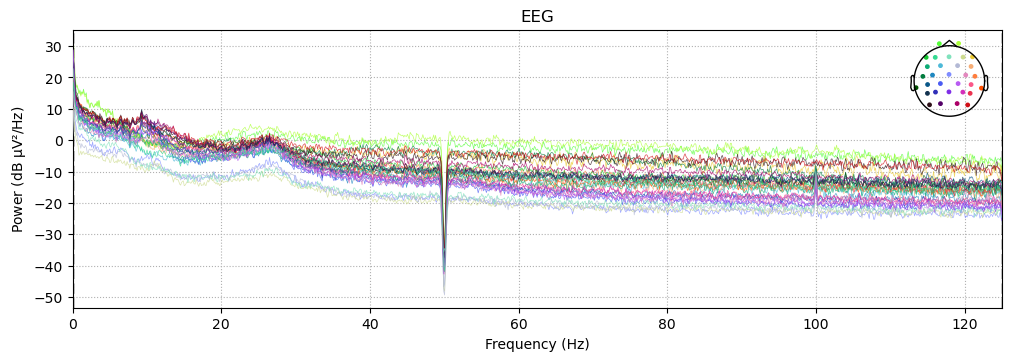

In [ ]:
line_freq = 50  # Set the line frequency to 50, as Antonin did: 
raw_resampled_line= raw_resampled.copy()
raw_resampled_line.notch_filter(freqs=line_freq)  # Apply notch filter to EEG channels only ?? OR: 49.5 to 50.5 in a method ??
# Plot the data to visualize the effect of the notch filter
raw_resampled_line.plot_psd()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Using pyopengl with version 3.1.6
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


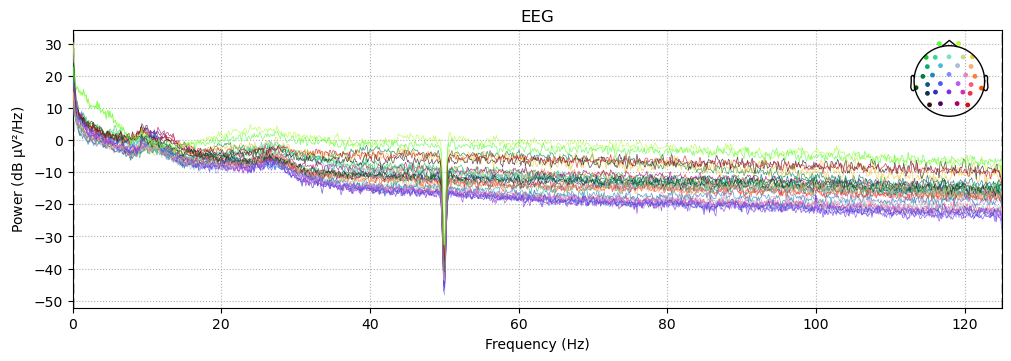

In [ ]:
raw_resampled_line_reref = raw_resampled_line.copy()
raw_resampled_line_reref.set_eeg_reference(ref_channels='average')
raw_resampled_line_reref.plot()
raw_resampled_line_reref.plot_psd()

In [ ]:
raw_resampled_line_reref_interp = raw_resampled_line_reref.copy()
# Assign the mne object to the NoisyChannels class. The resulting object will be the place where all following methods are performed.
noisy_data = NoisyChannels(raw_resampled_line_reref, random_state=1337)
# find bad by corr
noisy_data.find_bad_by_correlation()
print("Bad channels by correlation:", noisy_data.bad_by_correlation)
# find bad by deviation
noisy_data.find_bad_by_deviation()
print("Bad channels by deviation:", noisy_data.bad_by_deviation)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Bad channels by correlation: ['Fp1', 'Fp2', 'T7']
Bad channels by deviation: []


In [ ]:
noisy_data.find_bad_by_ransac(channel_wise=True, max_chunk_size=1) 
print("Bad channels by RANSAC:", noisy_data.bad_by_ransac)

Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 1
Total # of chunks: 28
Current chunk:
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28

RANSAC done!
Bad channels by RANSAC: [np.str_('F4'), np.str_('FC1')]


In [ ]:
bads

['T8', np.str_('FC1'), 'T7']

In [ ]:
# get channel names marked as bad and assign them into bads of the data from the step before
raw_resampled_line_reref_interp.info["bads"] = noisy_data.get_bads()
bads = noisy_data.get_bads()

In [ ]:
bads

[np.str_('FC1'), 'T7', np.str_('F4'), 'Fp2', 'Fp1']

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 97.0 mm
Computing interpolation matrix from 26 sensor positions
Interpolating 5 sensors
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


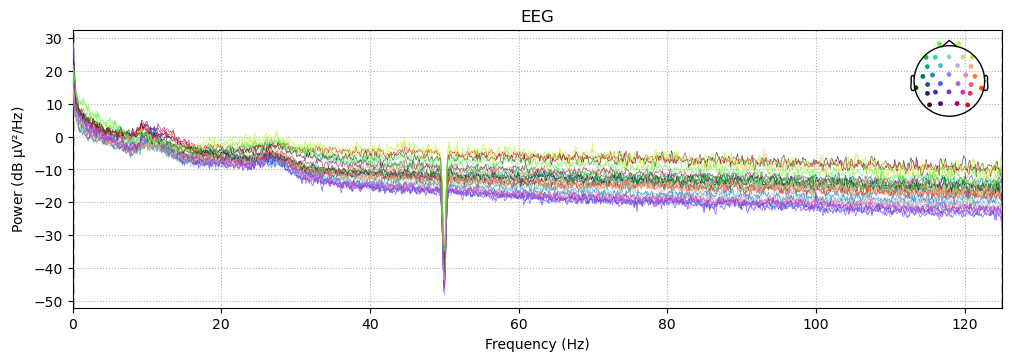

In [ ]:
raw_resampled_line_reref_interp.interpolate_bads()
# plot psd
raw_resampled_line_reref_interp.plot_psd()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 2751 samples (11.004 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


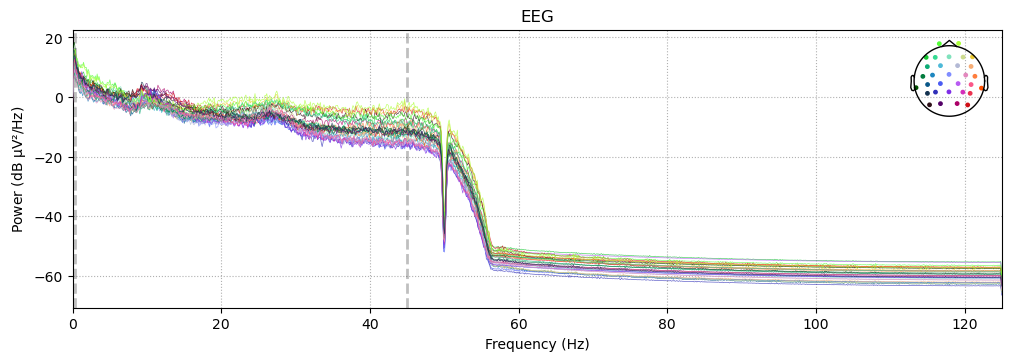

In [ ]:
raw_resampled_line_reref_interp_filt = raw_resampled_line_reref_interp.copy()
# Define the bandpass filter frequency range
low_freq = 0.3  # Lower cutoff frequency (in Hz)
#low_freq = 1
high_freq = 45.0  # Upper cutoff frequency (in Hz)
# Apply the bandpass filter
raw_resampled_line_reref_interp_filt.filter(l_freq=low_freq, h_freq=high_freq, method='fir', phase='zero') # check method and phase
# plot psd
raw_resampled_line_reref_interp_filt.plot_psd()

In [ ]:
raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=1.0, h_freq=None)
# you can try and see lower for heart artifacts but other components may get worse
#raw_ica = raw_resampled_line_reref_interp_filt.copy().filter(l_freq=0.1, h_freq=None)


# set up and fit the ICA
ica = ICA(n_components=27, max_iter="auto", random_state=97) # initially 30
ica.fit(raw_ica)
ica

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by number: 27 components


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA took 1.2s.


<ipython-input-54-54a384f4a1b3>:8: RuntimeWarning: Using n_components=27 (resulting in n_components_=27) may lead to an unstable mixing matrix estimation because the ratio between the largest (13) and smallest (4.3e-29) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 26
  ica.fit(raw_ica)


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,52 iterations on raw data (104075 samples)
ICA components,27
Available PCA components,31
Channel types,eeg
ICA components marked for exclusion,—


Fraction of eeg variance explained by all components: 0.18215325317817066
Creating RawArray with float64 data, n_channels=28, n_times=104075
    Range : 0 ... 104074 =      0.000 ...   416.296 secs
Ready.
Using pyopengl with version 3.1.6


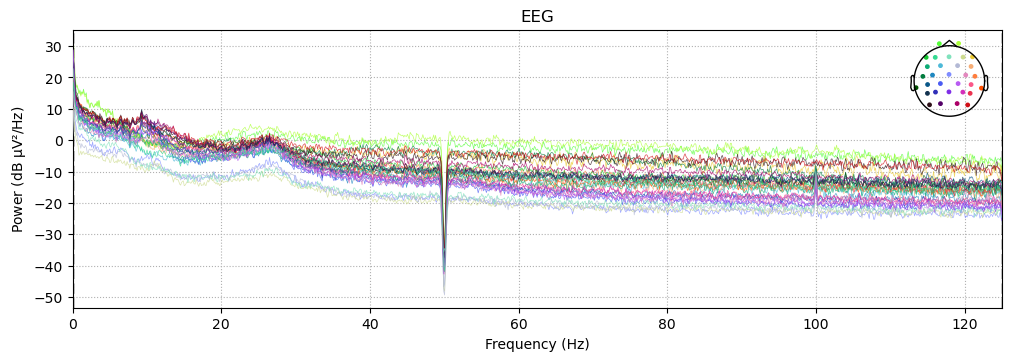

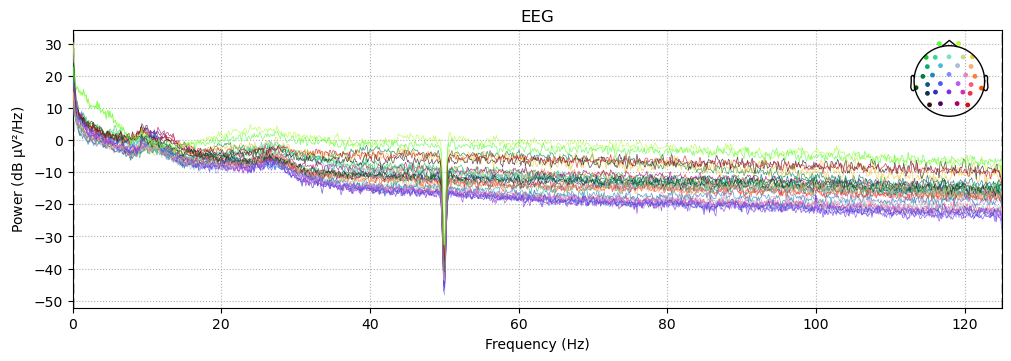

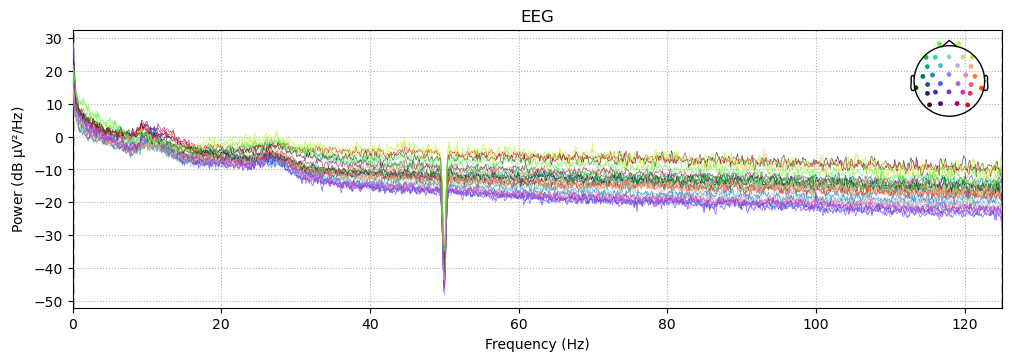

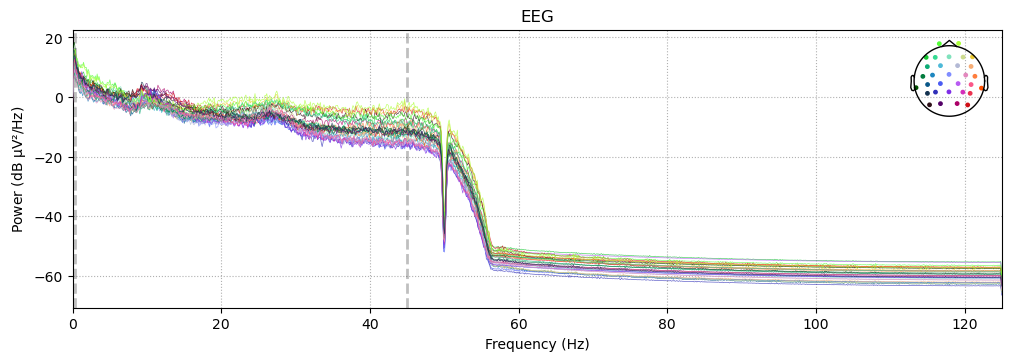

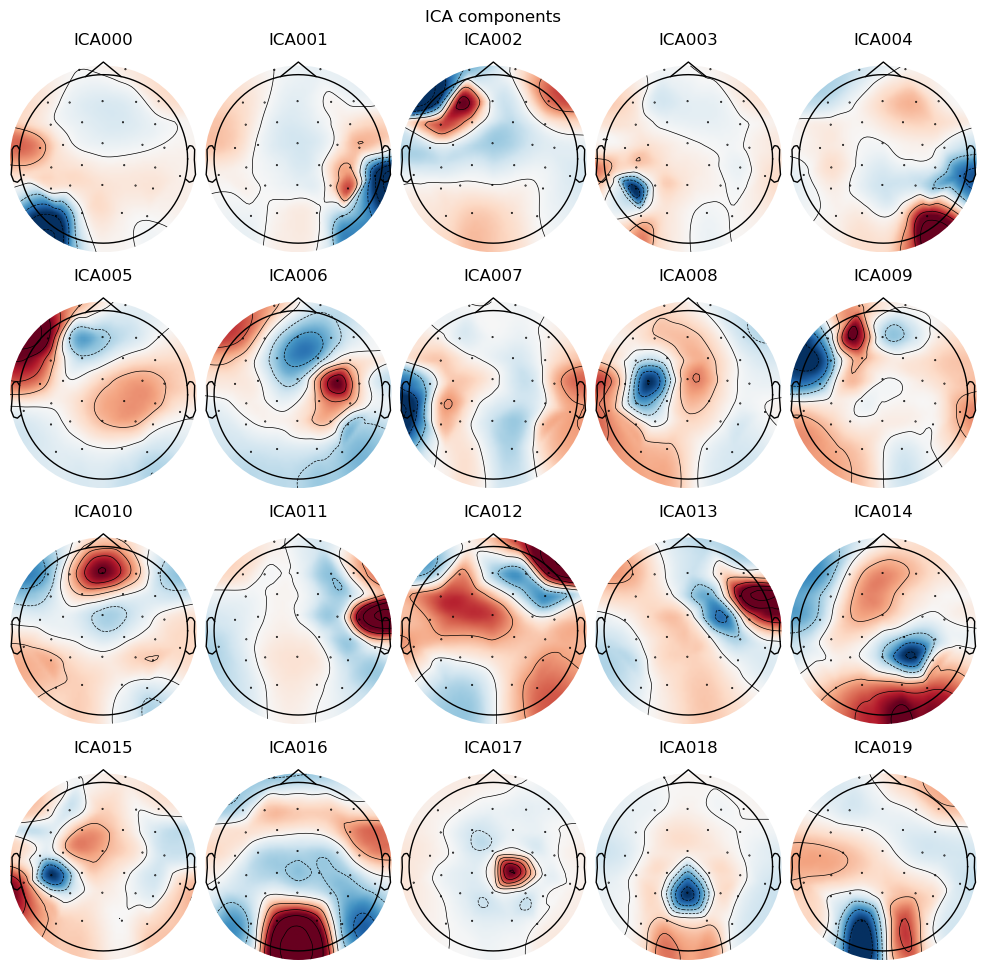

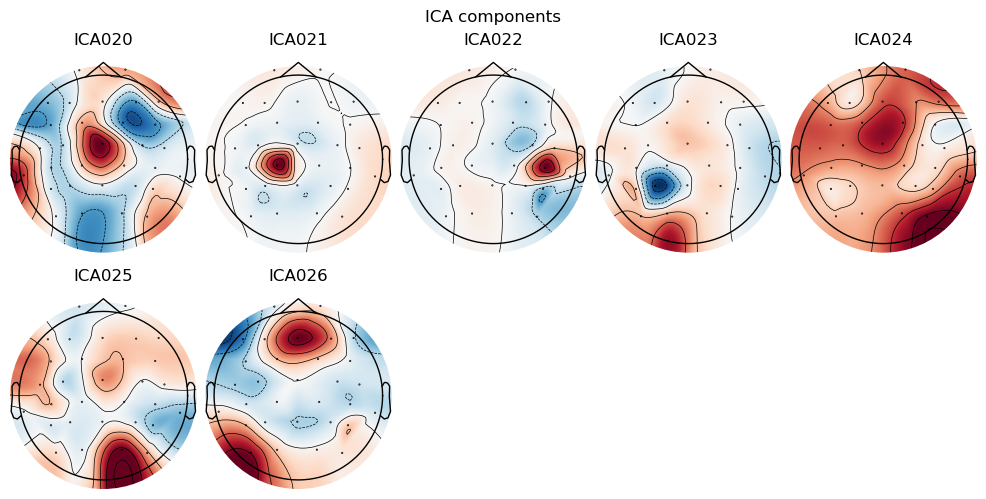

<ipython-input-55-f855e6352621>:14: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')
<ipython-input-55-f855e6352621>:14: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')


Predicted Probabilities: [0.67113423 0.7915675  0.935584   0.8205809  0.3369482  0.94766974
 0.9206785  0.72849166 0.9987335  0.798185   0.9616816  0.6729627
 0.65695953 0.5294217  0.99940693 0.87585336 0.9997968  0.6206015
 0.8961341  0.9909619  0.80774844 0.7953867  0.64173687 0.96036136
 0.9481734  0.99491847 0.379452  ]
Component Labels: ['brain', 'brain', 'muscle artifact', 'brain', 'muscle artifact', 'eye blink', 'brain', 'brain', 'brain', 'muscle artifact', 'brain', 'muscle artifact', 'muscle artifact', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'other']
Excluding components: [2, 4, 5, 9, 11, 12, 24, 26]
Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 8 ICA components
    Projecting back using 31 PCA components


In [ ]:
# print explained vars for ICAs
explained_var_ratio = ica.get_explained_variance_ratio(raw_ica)
for channel_type, ratio in explained_var_ratio.items():
    print(
        f"Fraction of {channel_type} variance explained by all components: " f"{ratio}"
    )

# plot ICs
raw_ica.load_data()
ica.plot_sources(raw_ica, show_scrollbars=False)
ica.plot_components()

# Automatically label components using the 'iclabel' method
component_dict = label_components(inst=raw_ica, ica=ica, method='iclabel')
# component_labels gives the labels

# Print the results
print("Predicted Probabilities:", component_dict['y_pred_proba'])
print("Component Labels:", component_dict['labels'])

# Extract the labels and probabilities
labels = component_dict['labels']
probabilities = component_dict['y_pred_proba']

# Identify components to exclude (not labeled as 'brain' with probability >= 0.5)
exclude_components = [
    idx for idx, (label, prob) in enumerate(zip(labels, probabilities))
    if label != 'brain' or prob < 0.5
]

# Print excluded components for verification
print(f"Excluding components: {exclude_components}")

# Remove the identified components from the preprocessed data
ica.exclude = exclude_components
raw_cleaned = ica.apply(raw_resampled_line_reref_interp_filt.copy())

In [ ]:
# Print excluded components for verification
print(f"Excluding components: {exclude_components}")

# Remove the identified components from the preprocessed data
ica.exclude = exclude_components
raw_cleaned = ica.apply(raw_resampled_line_reref_interp_filt.copy())

# Plot the cleaned data
raw_cleaned.plot()

Excluding components: [2, 4, 5, 9, 11, 12, 24, 26]
Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 8 ICA components
    Projecting back using 31 PCA components
Using pyopengl with version 3.1.6


Channels marked as bad:
none
Channels marked as bad:
none


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


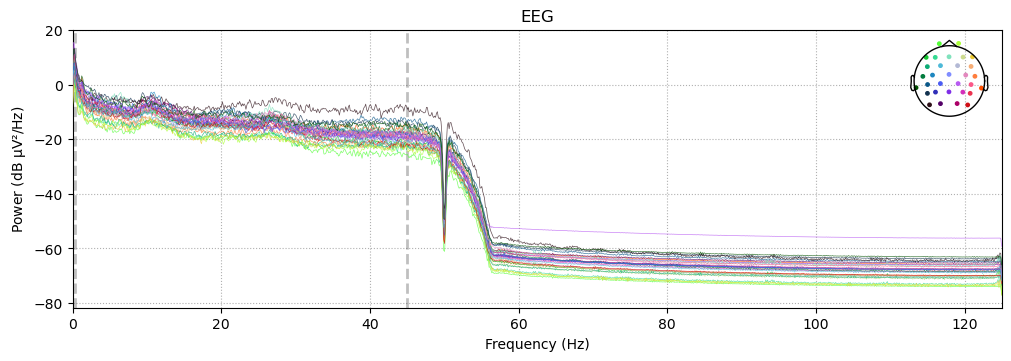

In [ ]:
raw_resampled_line_reref_interp_filt.plot_psd()
raw_cleaned.plot_psd()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/denizyilmaz/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


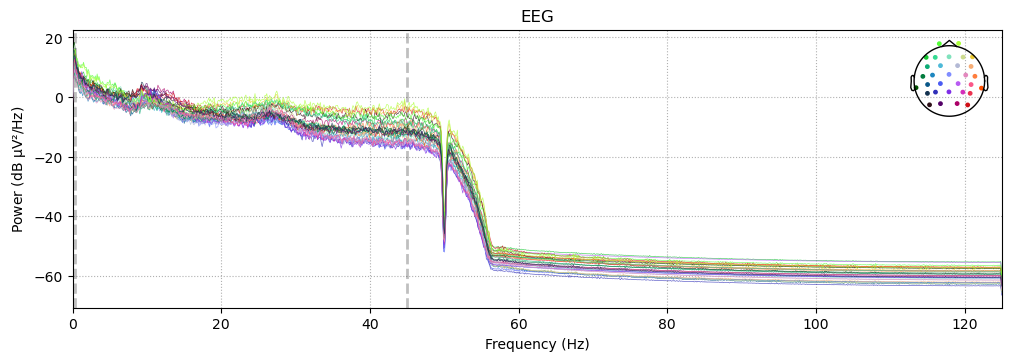

In [ ]:
raw_resampled_line_reref_interp_filt.plot_psd()

Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 0 ICA components
    Projecting back using 31 PCA components


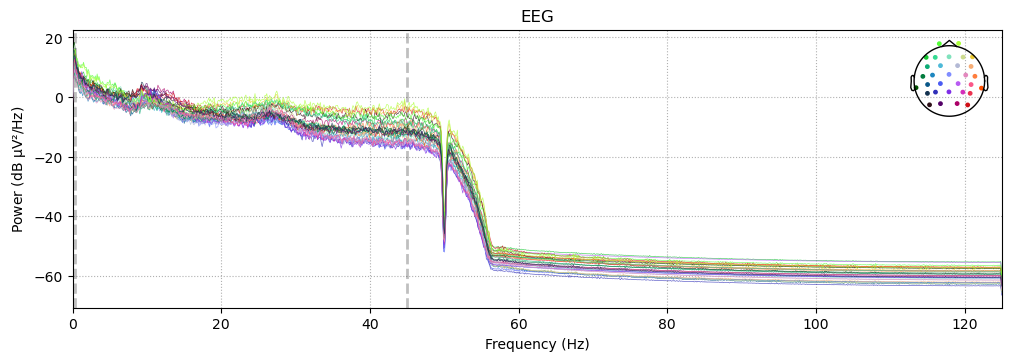

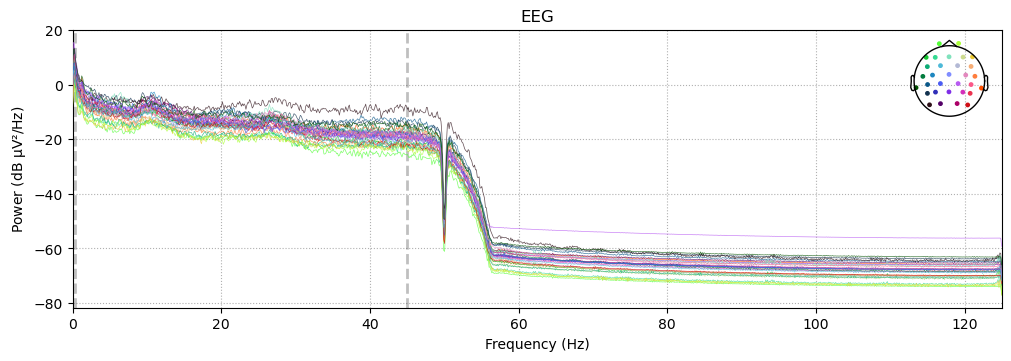

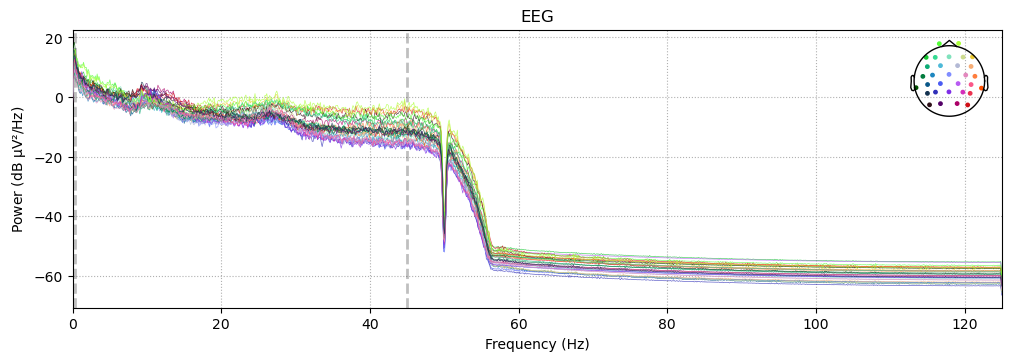

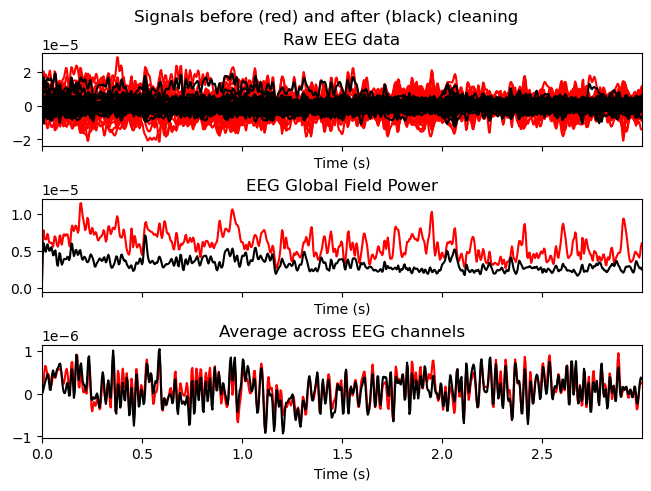

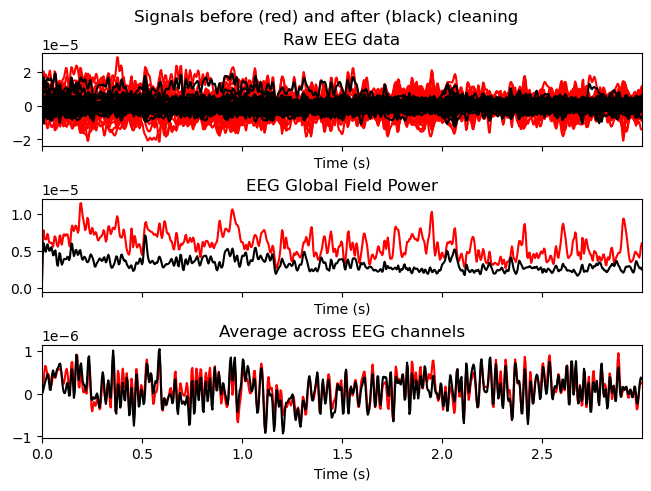

In [ ]:
ica.plot_overlay(raw_resampled_line_reref_interp_filt, exclude=ica.exclude)

Used Annotations descriptions: [np.str_('Comment/actiCAP Data On'), np.str_('New Segment/'), np.str_('R-peak')]
Not setting metadata
532 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 532 events and 276 original time points ...
3 bad epochs dropped


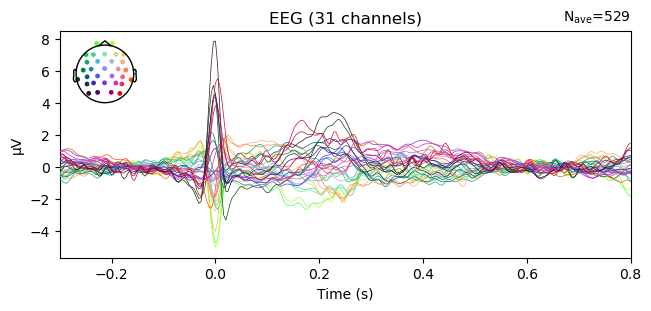

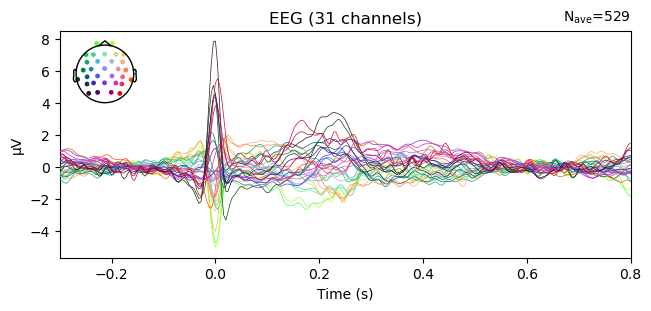

In [ ]:
heartbeat_events, event_id = mne.events_from_annotations(raw_resampled)

heartbeat_epochs = mne.Epochs(
    raw_resampled_line_reref_interp_filt, heartbeat_events,
    event_id=event_id, tmin=-0.3, tmax=0.8, 
    baseline=(None, 0), preload=True, event_repeated='drop'
)

heartbeat_evoked = heartbeat_epochs.average()
heartbeat_evoked.plot()